In [1]:
%load_ext autoreload
%autoreload 2

import functools
from math import pi

import numpy as np
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import scipy.signal
import tqdm
import xarray as xr

from fluxoniumcr import DATA_DIR
from fluxoniumcr.plotting.collision_heatmap import bin2d_maximum, make_colorbar, mycmap
from fluxoniumcr.qubits.fluxonium import Fluxonium
from fluxoniumcr.spectrum.autodiff import FunctionComposition, SampledFunction
from fluxoniumcr.spectrum.square_spectrum import calculate_square_spectrum
from fluxoniumcr.spectrum.planck import PlanckRampFunction

plt.style.use("fluxoniumcr.plotting.paper")

In [2]:
J12 = 97e-3 * 2*pi
fx2 = Fluxonium(
    EJ=3.52 * 2*pi,
    EC=1.18 * 2*pi,
    EL=0.88 * 2*pi,
    flux=0.5,
    dim=16,
    cutoff=128,
)
fx2_evals = fx2.eigenvalues
fx2_n_op = fx2.get_operator('charge')

In [4]:
parent_path = DATA_DIR/"time_domain/EJc=5.60,ECc=1.87,ELc=0.56,EJt=3.52,ECt=1.18,ELt=0.88,JC=0.097"
dataset = xr.load_dataset(parent_path/"random_duration.hdf5")
amp_sweep_dataset = xr.load_dataset(parent_path/"planck_taper_amplitude_sweep.hdf5")
Ω0 = dataset.amplitude.plot_unit
ramp_duration = amp_sweep_dataset.ramp_duration.item()

In [5]:
charge_op_dataset = xr.load_dataset(
    DATA_DIR/"charge_operator"
    / f"EJ=5.60,EC=1.87,EL=0.56"
    / f"driven_charge_operator.hdf5"
)

In [6]:
bra = 0
ket = 1
harmonic = -5

matrix_element_0_data = charge_op_dataset.matrix.sel(bra=bra, ket=ket, harmonic=harmonic).data.ravel()
delta = charge_op_dataset.amplitude[:2].diff('amplitude').item()

matrix_element_1_data = scipy.signal.savgol_filter(
    matrix_element_0_data,
    polyorder=2,
    window_length=3,
    deriv=1,
    delta=delta,
)
matrix_element_2_data = scipy.signal.savgol_filter(
    matrix_element_0_data,
    polyorder=2,
    window_length=3,
    deriv=2,
    delta=delta,
)
matrix_element_func = SampledFunction(
    charge_op_dataset.amplitude.data,
    matrix_element_0_data,
    matrix_element_1_data,
    matrix_element_2_data,
)
transition_freq_0_data = (
    charge_op_dataset.quasienergy.isel(frequency=0, ket=bra).data
    - charge_op_dataset.quasienergy.isel(frequency=0, ket=ket).data
    + harmonic*charge_op_dataset.frequency.item()
)
transition_freq_1_data = scipy.signal.savgol_filter(
    transition_freq_0_data,
    polyorder=1,
    window_length=2,
    deriv=1,
    delta=delta,
)
transition_freq_func = SampledFunction(
    charge_op_dataset.amplitude.data,
    transition_freq_0_data,
    transition_freq_1_data,
)

leak_err_data = []
spectrum_data = []

for amp in tqdm.tqdm(dataset.amplitude.data):
    ramp_func = PlanckRampFunction(ramp_duration, amp)

    envelope_func = FunctionComposition(matrix_element_func, ramp_func)
    instfreq_func = FunctionComposition(transition_freq_func, ramp_func)

    t_data = np.linspace(0, ramp_duration, 101)
    spectrum = calculate_square_spectrum(
        envelope_func(t_data),
        envelope_func.derivative(1)(t_data),
        envelope_func.derivative(2)(t_data),
        instfreq_func(t_data),
        instfreq_func.derivative(1)(t_data),
        t_data[1] - t_data[0],
    )

    freq = -(fx2_evals[2] - fx2_evals[1])
    leak_err = 0.25*J12**2 * abs(fx2_n_op[1, 2])**2 * spectrum(freq)
    leak_err_data.append(leak_err)
    spectrum_data.append(spectrum)
    
leak_err_data = np.array(leak_err_data)

100%|███████████████████████████████████████████████| 701/701 [00:00<00:00, 1061.01it/s]


In [7]:
avg_prob = 0.25 * (
    dataset.average_transition_probability.sel(final_state=2, initial_state=4)
    + dataset.average_transition_probability.sel(final_state=2, initial_state=5)
)
unitary = dataset.unitary
numeric_prob = 0.25 * (
    abs(unitary.sel(final_state=2, initial_state=4))**2
    + abs(unitary.sel(final_state=2, initial_state=5))**2
)
amp_sweep_unitary = amp_sweep_dataset.unitary
amp_sweep_numeric_prob = 0.25 * (
    abs(amp_sweep_unitary.sel(final_state=2, initial_state=4).squeeze())**2
    + abs(amp_sweep_unitary.sel(final_state=2, initial_state=5).squeeze())**2
)

In [8]:
from matplotlib.legend_handler import HandlerBase


class HandlerFilledLine(HandlerBase):
    def create_artists(
            self,
            legend,
            orig_handle,
            xdescent,
            ydescent,
            width,
            height,
            fontsize,
            trans,
    ):
        line_color = orig_handle.get_color()
        fill_color = orig_handle.get_fill_color()
        alpha = orig_handle.get_alpha()

        # Create rectangle (error band)
        patch = mpl.patches.Rectangle(
            (xdescent, ydescent),
            width, height,
            facecolor=fill_color,
            alpha=alpha,
            edgecolor='none',
            transform=trans
        )

        # Create central line
        line = mpl.lines.Line2D(
            [xdescent, xdescent + width],
            [ydescent + height/2, ydescent + height/2],
            color=line_color,
            linewidth=plt.rcParams['lines.linewidth'],
            solid_capstyle='butt',
            transform=trans
        )

        return [patch, line]
    
    
class FilledLine:
    def __init__(self, line_color, fill_color, alpha=0.3):
        self._line_color = line_color
        self._fill_color = fill_color
        self._alpha = alpha

    def get_color(self):
        return self._line_color

    def get_fill_color(self):
        return self._fill_color

    def get_alpha(self):
        return self._alpha

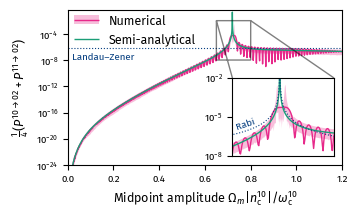

In [9]:
fig, ax0 = plt.subplots(
    figsize=(85/25.4, 50/25.4),
)

ax0.set_yscale('log')
ax0.set_xlim(0.0, 1.2)
ax0.set_ylim(1e-24, 5e-1)

axins = ax0.inset_axes(
    [0.60, 0.06, 0.37, 0.5],
    xlim=(0.65, 0.80),
    ylim=(1e-8, 1e-2),
)
axins.set_yscale('log')
axins.set_yticks([1e-8, 1e-5, 1e-2])
axins.tick_params(
#     left=False,
#     labelleft=False,
#     right=True,
#     labelright=True,
    bottom=False,
    labelbottom=False,
)#, top=True, labeltop=True)

inset_indicator = ax0.indicate_inset_zoom(axins, edgecolor="black")
inset_indicator.connectors[0].set_visible(False)
inset_indicator.connectors[1].set_visible(True)
inset_indicator.connectors[2].set_visible(False)
inset_indicator.connectors[3].set_visible(True)

ac_idx = np.argmin(abs(transition_freq_0_data + (fx2_evals[2] - fx2_evals[1])))
ac_amp = charge_op_dataset.amplitude.data[ac_idx]
gap_size = abs(2*J12 * matrix_element_0_data[ac_idx] * fx2_n_op[1, 2])
landau_zener_err = 0.25 * (
    2*np.pi* gap_size**2/abs(4 * ac_amp/ramp_duration * transition_freq_1_data[ac_idx])
    * 2  # Multiply by two for two traversals.
)

for ax in (ax0, axins):
    ax.plot(
        amp_sweep_dataset.amplitude/Ω0,
        amp_sweep_numeric_prob,
        c='C5',
        zorder=-2,
        label=r'Numerical CNOT',
    )
    ax.fill_between(
        dataset.amplitude/Ω0,
        numeric_prob.quantile(1.0, dim='duration'),
        numeric_prob.quantile(0.1, dim='duration'),
        fc='C5',
        alpha=0.3,
        zorder=-10,
        label=r'Numerical $t_\mathrm{p}=\infty$',
    )

    ax.plot(
        dataset.amplitude/Ω0,
        leak_err_data,
        c='C4',
        zorder=0,
        label='Semi-analytical'
    )
    
annotation_color = 'C0'  #plt.rcParams['grid.color']

ax0.axhline(
    landau_zener_err,
#     zorder=-20,
    c=annotation_color,
    lw=plt.rcParams['grid.linewidth'],
    ls=':'
)
    
ax0.set_xlabel(r"Midpoint amplitude $\Omega_m|n_\mathrm{c}^{10}|/\omega_\mathrm{c}^{10}$")
ax0.set_ylabel(r"$\frac{1}{4}(P^{10\to02} + P^{11\to02})$")
ax0.legend(
    loc='upper left',
    bbox_to_anchor=(0, 1.0),
    borderpad=0,
)

ax0.annotate(
    "Landau–Zener",
    (0, landau_zener_err),
    (3, -3),
    textcoords='offset points',
    va='top',
    ha='left',
    fontsize=plt.rcParams['ytick.labelsize'],
    c=annotation_color,
)


custom_handle = FilledLine('C5', 'C5', alpha=0.3)
plt.legend(
    [
        custom_handle,
        mpl.lines.Line2D([], [], c='C4', solid_capstyle='butt'),
    ],
    ['Numerical', 'Semi-analytical'],
    handler_map={FilledLine: HandlerFilledLine()},
    loc='upper left',
    bbox_to_anchor=(0, 1.01),
    borderpad=0,
)

detuning_data = (
    (dataset.amplitude - ac_amp)
    * transition_freq_func.derivative(1)(ac_amp)
)
axins.plot(
    dataset.amplitude/Ω0,
    gap_size**2/(4*detuning_data**2 + gap_size**2),
#     zorder=-20,
    c=annotation_color,
    lw=plt.rcParams['grid.linewidth'],
    ls=':'
)
axins.annotate(
    "Rabi",
    (0.65, 1e-6),
    (2, -1),
    textcoords='offset points',
    fontsize=plt.rcParams['ytick.labelsize'],
    c=annotation_color,
    va='bottom',
    ha='left',
    rotation=19,
)

fig.subplots_adjust(
    bottom=0.2,
    left=0.16,
    right=0.98,
    top=0.99,
)
fig.savefig("semi_analytic_leakage_comparison.pdf")

In [13]:
print(
    f"Avoided crossing amplitude [dimensionless]: {ac_amp/Ω0}"
)
print(
    f"Avoided crossing gap size [kHz]: {gap_size/(2*pi) * 1e6:.2f}"
)

Avoided crossing amplitude [dimensionless]: 0.72
Avoided crossing gap size [kHz]: 50.14


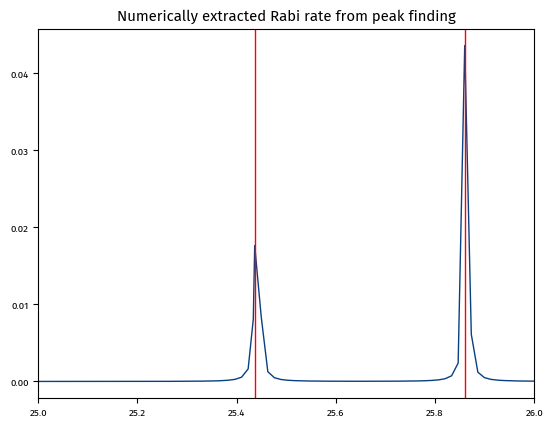

In [15]:
peak_indices, _ = scipy.signal.find_peaks(
    avg_prob,
    height=1e-5,
)

plt.plot(
    dataset.amplitude,
    avg_prob,
)
plt.xlim(25, 26)

plt.title("Numerically extracted Rabi rate from peak finding")
plt.axvline(dataset.amplitude.data[peak_indices[0]], c='red')
plt.axvline(dataset.amplitude.data[peak_indices[1]], c='red')

In [17]:
implied_rabi_splitting = transition_freq_func.derivative(1)(
    dataset.amplitude.data[peak_indices[0]]
) * np.diff(dataset.amplitude.data[peak_indices]).item()

print("Rabi splitting from peaks:", implied_rabi_splitting)

rabi_splitting = abs(
    2 * J12
    * charge_op_dataset.matrix.isel(amplitude=ac_idx).sel(bra=1, ket=1, harmonic=-1).item()
    * fx2_n_op[0, 1]
)
print("Rabi splitting from semi-analytics:", rabi_splitting)

Rabi splitting from peaks: 0.04153793482378994
Rabi splitting from semi-analytics: 0.04083005798179506
